# RL - Chapter 6 - TD - Windy Gridworld - Sarsa


In [44]:
# generate the table of contents
from scripts.toc import generate_toc

path = 'ch_6_TD_p2_windy_gridworld.ipynb'
generate_toc(path)

## Table of Contents

- [RL - Chapter 6 - TD - Windy Gridworld - Sarsa](#rl-chapter-6-td-windy-gridworld-sarsa)
  - [Windy Gridworld environment](#windy-gridworld-environment)
  - [Sarsa](#sarsa)
  - [result](#result)

In [45]:
# import libraries and configure the notebook
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# set decimal precision for numpy arrays
np.set_printoptions(precision=1, suppress=True)

## Windy Gridworld environment


In [46]:
# Windy Gridworld environment
class WindyGridworld:
    def __init__(self):
        self.y_max = 7
        self.x_max = 10
        self.start_state = (0, 3)
        self.goal_state = (7, 3)
        # wind strength for each column
        self.wind = [0, 0, 0, 1, 1, 1, 2, 2, 1, 0]
        # action space: up, down, left, right
        actions = [(x, y) for x in range(-1, 2) for y in range(-1, 2)]  # if abs(x) + abs(y) != 0
        self.actions = actions
        # self.actions = [(0, 1), (0, -1), (-1, 0), (1, 0)]
        self.n_actions = len(self.actions)

## Sarsa


In [47]:
# define the SARSA control agent
class Sarsa:
    def __init__(self, env: WindyGridworld, alpha=0.5, gamma=1.0, epsilon=0.1, n_episodes=500):
        self.env = env
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.n_episodes = n_episodes
        self.n_steps_per_episode = []
        # initialize Q-values to zero
        self.Q = defaultdict(lambda: np.zeros(self.env.n_actions))

    def run(self):
        n_total_steps = 0
        for episode in range(self.n_episodes):
            print(f'Episode {episode + 1}/{self.n_episodes}', end='\r')
            state = self.env.start_state
            action = self.choose_action(state)
            done = False
            n_steps = 0
            while n_steps < 10000:
                next_state, reward, done = self.step(state, action)
                next_action = self.choose_action(next_state)
                # update Q-value using Sarsa update rule
                td_target = reward + self.gamma * self.Q[next_state][next_action]
                td_error = td_target - self.Q[state][action]
                self.Q[state][action] += self.alpha * td_error
                state, action = next_state, next_action
                n_steps += 1
                if done:
                    break
            # ensure goal state has zero value
            self.Q[self.env.goal_state] = np.zeros(self.env.n_actions)
            n_total_steps += n_steps
            self.n_steps_per_episode.append(n_steps)

    def step(self, state, action):
        '''take action and return next state, reward, and done flag'''
        x, y = state
        dx, dy = self.env.actions[action]
        wind_strength = self.env.wind[x]
        x += dx
        y += dy
        y += wind_strength
        # keep within grid boundaries
        x = max(0, min(self.env.x_max - 1, x))
        y = max(0, min(self.env.y_max - 1, y))
        next_state = (x, y)
        done = next_state == self.env.goal_state
        reward = 0 if done else -1
        return next_state, reward, done

    def choose_action(self, state):
        '''epsilon-greedy action selection '''
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.env.n_actions)
        else:
            return np.argmax(self.Q[state])

## result


In [48]:
# run the MC prediction
env = WindyGridworld()
sarsa = Sarsa(env, alpha=0.5, n_episodes=300, epsilon=0.1)
sarsa.run()

In [49]:
# find path from start to goal using learned policy
state = env.start_state
path = [state]
while state != env.goal_state:
    action = np.argmax(sarsa.Q[state])
    dx, dy = env.actions[action]
    x, y = state
    wind_strength = env.wind[x]
    x += dx
    y += dy
    y += wind_strength
    # keep within grid boundaries
    x = max(0, min(env.x_max - 1, x))
    y = max(0, min(env.y_max - 1, y))
    state = (x, y)
    path.append(state)

    if len(path) > 100:  # prevent infinite loop in case of policy not reaching goal
        print("Policy did not reach goal within 100 steps.")
        break

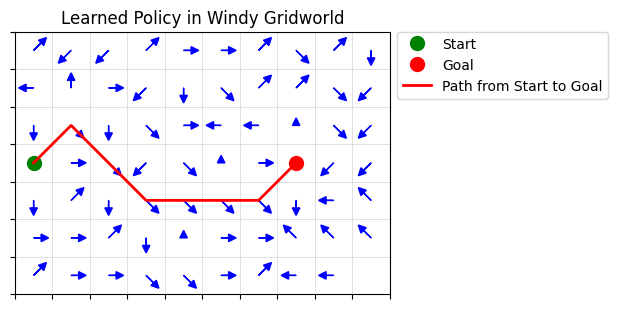

In [50]:
# plot gridworld with learned policy

# plot grid
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(env.start_state[0], env.start_state[1], 'go', markersize=10, label='Start')
ax.plot(env.goal_state[0], env.goal_state[1], 'ro', markersize=10, label='Goal')
# plot learned policy
for state, actions in sarsa.Q.items():
    if state in [env.start_state, env.goal_state]:
        continue
    best_action = np.argmax(actions)
    dx, dy = env.actions[best_action]
    ax.arrow(state[0], state[1], dx * 0.2, dy * 0.2, head_width=0.2, head_length=0.2, fc='blue', ec='blue')

# plot path from start to goal
path_x = [s[0] for s in path]
path_y = [s[1] for s in path]
ax.plot(path_x, path_y, 'r-', linewidth=2, label='Path from Start to Goal')

# move 0.5 in x and y to center arrows in cells
ax.set_xticks(np.arange(-0.5, env.x_max, 1))
ax.set_yticks(np.arange(-0.5, env.y_max, 1))
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.grid(True, which='both', color='lightgray', linewidth=0.5)
ax.set_title('Learned Policy in Windy Gridworld')
ax.set_xlim(-0.5, env.x_max - 0.5)
ax.set_ylim(-0.5, env.y_max - 0.5)
ax.set_aspect('equal')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0.)
fig.subplots_adjust(right=0.75)
plt.show()

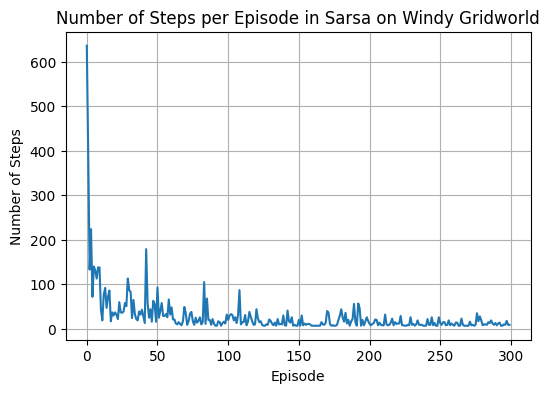

In [51]:
# plot number of steps per episode
plt.figure(figsize=(6, 4))
plt.plot(sarsa.n_steps_per_episode)
plt.xlabel('Episode')
plt.ylabel('Number of Steps')
plt.title('Number of Steps per Episode in Sarsa on Windy Gridworld')
plt.grid()
plt.show()